In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

print("--- 1. LOADING PROBABILITY MAP & ID CROSSWALK ---")
# 1. Load your master probability map which contains player archetypes
prob_map = pd.read_csv('master_probability_map_2020_2025.csv')
prob_map['season'] = prob_map['season'].astype(int)
# Clean player_id to remove trailing '.0' if present
prob_map['player_id'] = prob_map['player_id'].astype(str).str.replace('.0', '', regex=False)

# 2. Download the official NFLverse ID Dictionary directly from GitHub
print("Downloading NFLverse ID Crosswalk...")
id_url = "https://github.com/nflverse/nflverse-data/releases/download/players/players.csv"
id_df = pd.read_csv(id_url, low_memory=False)
# Select and clean relevant ID columns for merging
id_map = id_df[['gsis_id', 'pff_id']].dropna().copy()
id_map['pff_id'] = id_map['pff_id'].astype(str).str.replace('.0', '', regex=False)

# 3. Merge GSIS IDs onto your Probability Map to link archetypes to official player IDs
prob_map = prob_map.merge(id_map, left_on='player_id', right_on='pff_id', how='inner')
# Identify columns representing cluster probabilities for future use
cluster_cols = [c for c in prob_map.columns if '_' in c and c not in ['player_id', 'pff_id', 'gsis_id']]

print("--- 2. DOWNLOADING PLAY-BY-PLAY & PARTICIPATION DATA ---")
years_to_pull = [2020, 2021, 2022, 2023, 2024]
pbp_list = []
partic_list = []

# Loop through the years and download the parquet files directly from NFLverse
for year in years_to_pull:
    print(f"Fetching {year} data...")
    # Play by play data
    pbp_url = f"https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_{year}.parquet"
    pbp_list.append(pd.read_parquet(pbp_url))

    # Player participation data (which 11 guys were on the field)
    partic_url = f"https://github.com/nflverse/nflverse-data/releases/download/pbp_participation/pbp_participation_{year}.parquet"
    partic_list.append(pd.read_parquet(partic_url))

pbp = pd.concat(pbp_list, ignore_index=True)
partic = pd.concat(partic_list, ignore_index=True)

# Filter play-by-play data for relevant play types (pass/run), valid EPA, and Regular Season only
pbp = pbp[
    (pbp['play_type'].isin(['pass', 'run'])) &
    (pbp['epa'].notna()) &
    (pbp['season_type'] == 'REG')
]

# Keep only the essential columns for regression, including 'posteam' for future use
pbp = pbp[['game_id', 'play_id', 'season', 'epa', 'down', 'ydstogo', 'yardline_100', 'shotgun', 'play_type', 'posteam']]

# Filter participation data to include only defense_players and drop nulls
partic = partic[['nflverse_game_id', 'play_id', 'defense_players']].dropna()

# Merge PBP and Participation data on game_id and play_id
pbp_full = pbp.merge(partic, left_on=['game_id', 'play_id'], right_on=['nflverse_game_id', 'play_id'], how='inner')


print("--- 3. BUILDING DEFENSIVE LINEUP VECTORS ---")
# 1. Explode the defense_players string (e.g., "ID1;ID2;ID3" -> 11 separate rows per play)
pbp_full['defense_players'] = pbp_full['defense_players'].str.split(';')
pbp_exploded = pbp_full.explode('defense_players').rename(columns={'defense_players': 'gsis_id'})

# 2. Map the soft GMM probabilities (archetype probabilities) to each defender on the field
play_defenders = pbp_exploded.merge(
    prob_map[['gsis_id', 'season'] + cluster_cols],
    on=['gsis_id', 'season'],
    how='left'
)

# 3. Sum the probabilities for the 11 players on each play to create lineup vectors
lineup_vectors = play_defenders.groupby(['game_id', 'play_id'])[cluster_cols].sum().reset_index()

# 4. Re-attach the target variable (EPA) and context controls to the lineup vectors
regression_df = lineup_vectors.merge(pbp_full[['game_id', 'play_id', 'epa', 'down', 'ydstogo', 'yardline_100', 'shotgun']], on=['game_id', 'play_id'])

# 5. Data Hygiene: Drop plays where we couldn't match enough players (less than 9.5 total probability implies missing players)
regression_df['total_prob'] = regression_df[cluster_cols].sum(axis=1)
regression_df = regression_df[regression_df['total_prob'] >= 9.5].copy()


print("--- 4. RIDGE REGRESSION (VALUATION) ---")
# Fill missing context variables with default values
regression_df['down'] = regression_df['down'].fillna(1)
regression_df['shotgun'] = regression_df['shotgun'].fillna(0)

# Define features (X) including cluster probabilities and control variables, and target (y) EPA
X = regression_df[cluster_cols + ['down', 'ydstogo', 'yardline_100', 'shotgun']]
y = regression_df['epa']

# Scale the continuous control variables to prevent them from dominating the regression
scaler = StandardScaler()
X_scaled = X.copy()
control_cols = ['down', 'ydstogo', 'yardline_100']
X_scaled[control_cols] = scaler.fit_transform(X[control_cols])

# Fit Ridge Regression with an alpha of 10.0 for regularization
ridge = Ridge(alpha=10.0)
ridge.fit(X_scaled, y)

# Extract Coefficients to understand the impact of each archetype and control variable
coefs = pd.DataFrame({
    'Archetype': X.columns,
    'EPA_Impact': ridge.coef_
})

# Isolate just the player cluster coefficients, sort, and display
cluster_coefs = coefs[coefs['Archetype'].isin(cluster_cols)].sort_values('EPA_Impact')

print("\n DEFENSIVE ARCHETYPE VALUATIONS (Negative EPA = Better Defense)")
display(cluster_coefs)

# Save the regression results to a CSV file
cluster_coefs.to_csv('archetype_epa_valuations.csv', index=False)
print("\n✅ Regression Complete! Saved as 'archetype_epa_valuations.csv'")

--- 1. LOADING PROBABILITY MAP & ID CROSSWALK ---
--- 2. DOWNLOADING PLAY-BY-PLAY & PARTICIPATION DATA ---
Fetching 2020 data...
Fetching 2021 data...
Fetching 2022 data...
Fetching 2023 data...
Fetching 2024 data...
--- 3. BUILDING DEFENSIVE LINEUP VECTORS ---
--- 4. RIDGE REGRESSION (VALUATION) ---

 DEFENSIVE ARCHETYPE VALUATIONS (Negative EPA = Better Defense)


,Archetype,EPA_Impact
17,ED_3,-0.049791
19,DI_1,-0.039992
5,S_0,-0.035897
14,ED_0,-0.035207
3,CB_3,-0.020347
16,ED_2,-0.015220
20,DI_2,-0.012915
6,S_1,-0.008764
11,LB_1,-0.008289
26,DI_R,-0.007323



✅ Regression Complete! Saved as 'archetype_epa_valuations.csv'


In [ ]:
import pandas as pd
import numpy as np

print("--- 1. ASSIGNING DOMINANT ARCHETYPES ---")
# Identify cluster columns from prob_map (excluding IDs and season)
cluster_cols = [c for c in prob_map.columns if '_' in c and c not in ['player_id', 'pff_id', 'gsis_id', 'season']]
# Filter for only numeric cluster columns to avoid issues with idxmax
numeric_cluster_cols = prob_map[cluster_cols].select_dtypes(include=[np.number]).columns.tolist()

# Assign the dominant cluster (archetype) to each player based on the highest probability
prob_map['dominant_cluster'] = prob_map[numeric_cluster_cols].idxmax(axis=1)
# Extract the base position (e.g., 'CB', 'S', 'LB') from the dominant cluster name
prob_map['base_pos'] = prob_map['dominant_cluster'].str.split('_').str[0]

# Define a function to map specific positions to broader 'scheme_pos' categories (e.g., ED/DI -> DL)
def map_to_front_7(pos):
    if pos in ['ED', 'DI']: return 'DL'
    return pos
prob_map['scheme_pos'] = prob_map['base_pos'].apply(map_to_front_7)


print("--- 2. BUILDING THE PLAY-BY-PLAY LINEUPS ---")
# Re-explode the pbp_full DataFrame to have one row per player per play
pbp_exploded = pbp_full.explode('defense_players').rename(columns={'defense_players': 'gsis_id'})

# Merge with prob_map to get dominant cluster and scheme position for each player on each play
play_defenders = pbp_exploded.merge(
    prob_map[['gsis_id', 'season', 'dominant_cluster', 'scheme_pos']],
    on=['gsis_id', 'season'],
    how='inner'
)

# Group by game_id and play_id to build scheme strings and archetype lineups
# 1. Build the Scheme Strings (e.g., "4-2-5" for 4 DL, 2 LB, 5 DB)
scheme_counts = play_defenders.groupby(['game_id', 'play_id', 'scheme_pos']).size().unstack(fill_value=0)

# Combine CB and S counts into a 'DB' count for scheme string generation
if 'CB' in scheme_counts.columns and 'S' in scheme_counts.columns:
    scheme_counts['DB'] = scheme_counts['CB'] + scheme_counts['S']
else:
    scheme_counts['DB'] = 0

scheme_names = []
for idx, row in scheme_counts.iterrows():
    dl = int(row.get('DL', 0))
    lb = int(row.get('LB', 0))
    db = int(row.get('DB', 0))
    scheme_names.append(f"{dl}-{lb}-{db}")

# Create a DataFrame for schemes with game_id, play_id, and Base_Scheme
scheme_df = scheme_counts.reset_index()[['game_id', 'play_id']]
scheme_df['Base_Scheme'] = scheme_names

# 2. Build the Exact Archetype Lineup String (e.g., "CB_1 | CB_2 | DI_0...")
# Sort players within each play by dominant_cluster for consistent lineup string representation
play_defenders_sorted = play_defenders.sort_values(['game_id', 'play_id', 'dominant_cluster'])
archetype_lineups = play_defenders_sorted.groupby(['game_id', 'play_id'])['dominant_cluster'].apply(lambda x: ' | '.join(x)).reset_index()
archetype_lineups.rename(columns={'dominant_cluster': 'Archetype_Lineup'}, inplace=True)


print("--- 3. CALCULATING EPA FOR SCHEMES & LINEUPS ---")
# Merge scheme and archetype lineup data with relevant play-by-play information
lineup_pbp = pbp_full[['game_id', 'play_id', 'epa', 'play_type', 'down', 'ydstogo']].drop_duplicates(subset=['game_id', 'play_id'])
lineup_pbp = lineup_pbp.merge(scheme_df, on=['game_id', 'play_id'], how='inner')
lineup_pbp = lineup_pbp.merge(archetype_lineups, on=['game_id', 'play_id'], how='inner')

print(f"Health Check: Evaluating EPA across {len(lineup_pbp)} strictly unique plays.")

# Data Hygiene: Filter out plays that didn't have exactly 11 players in the Archetype_Lineup string
# This helps remove incomplete or anomalous plays.
lineup_pbp['Player_Count'] = lineup_pbp['Archetype_Lineup'].str.count(r'\|') + 1
lineup_pbp = lineup_pbp[lineup_pbp['Player_Count'] == 11]

# Calculate overall EPA by Base Scheme (minimum 1000 plays for statistical significance)
scheme_epa = lineup_pbp.groupby('Base_Scheme').agg(
    Plays=('epa', 'count'),
    Avg_EPA=('epa', 'mean')
).reset_index()

scheme_epa = scheme_epa[scheme_epa['Plays'] >= 1000].sort_values('Avg_EPA', ascending=True)

print("\n🏈 BROAD SCHEME PERFORMANCE (E.g., 4-2-5 vs 4-3-4)")
print("Negative EPA is better for the defense!")
display(scheme_epa)

# Calculate EPA by Exact Archetype Lineup (minimum 250 plays for statistical significance)
archetype_epa = lineup_pbp.groupby(['Base_Scheme', 'Archetype_Lineup']).agg(
    Plays=('epa', 'count'),
    Avg_EPA=('epa', 'mean')
).reset_index()

archetype_epa = archetype_epa[archetype_epa['Plays'] >= 100].sort_values('Avg_EPA', ascending=True)

print("\n🔬 TOP 10 SPECIFIC ARCHETYPE LINEUPS")
display(archetype_epa.head(10))

# Save the results to CSV files for further analysis or publication
scheme_epa.to_csv('base_scheme_epa.csv', index=False)
archetype_epa.to_csv('specific_archetype_lineups_epa.csv', index=False)

--- 1. ASSIGNING DOMINANT ARCHETYPES ---
--- 2. BUILDING THE PLAY-BY-PLAY LINEUPS ---
--- 3. CALCULATING EPA FOR SCHEMES & LINEUPS ---
Health Check: Evaluating EPA across 167909 strictly unique plays.

🏈 BROAD SCHEME PERFORMANCE (E.g., 4-2-5 vs 4-3-4)
Negative EPA is better for the defense!


,Base_Scheme,Plays,Avg_EPA
20,5-1-5,1840,-0.034776
21,5-2-4,6692,-0.022756
17,4-3-4,7698,-0.022511
15,4-1-6,9748,-0.021774
11,3-2-6,2339,-0.017078
16,4-2-5,48437,-0.007443
12,3-3-5,1107,0.000442



🔬 TOP 10 SPECIFIC ARCHETYPE LINEUPS


,Base_Scheme,Archetype_Lineup,Plays,Avg_EPA
7077,4-2-5,CB_1 | CB_4 | CB_4 | DI_1 | ED_0 | ED_2 | ED_3...,103,-0.312528
6900,4-2-5,CB_1 | CB_4 | CB_4 | DI_1 | DI_2 | ED_3 | ED_3...,156,-0.196735
6808,4-2-5,CB_1 | CB_4 | CB_4 | DI_1 | DI_2 | ED_0 | ED_0...,155,-0.147456
6825,4-2-5,CB_1 | CB_4 | CB_4 | DI_1 | DI_2 | ED_0 | ED_1...,142,-0.147269
6151,4-2-5,CB_1 | CB_4 | CB_4 | DI_0 | DI_1 | ED_0 | ED_2...,102,-0.141552
7188,4-2-5,CB_1 | CB_4 | CB_4 | DI_2 | DI_2 | ED_0 | ED_3...,103,-0.140604
13993,5-2-4,CB_2 | CB_4 | DI_0 | DI_2 | DI_2 | ED_0 | ED_3...,136,-0.105206
6816,4-2-5,CB_1 | CB_4 | CB_4 | DI_1 | DI_2 | ED_0 | ED_0...,268,-0.098561
6249,4-2-5,CB_1 | CB_4 | CB_4 | DI_0 | DI_2 | ED_0 | ED_0...,130,-0.092367
6768,4-2-5,CB_1 | CB_4 | CB_4 | DI_1 | DI_1 | ED_0 | ED_3...,127,-0.089796


In [ ]:
import pandas as pd

print("--- 1. PREPPING SEASONAL DATA ---")
# Grab the season column from pbp_full along with our play identifiers
season_data = pbp_full[['game_id', 'play_id', 'season']].drop_duplicates(subset=['game_id', 'play_id'])

# Merge the season data onto our previously built scheme and lineup dataframes
trend_df = season_data.merge(scheme_df, on=['game_id', 'play_id'], how='inner')
trend_df = trend_df.merge(archetype_lineups, on=['game_id', 'play_id'], how='inner')

# Clean up any plays that didn't have exactly 11 players in the Archetype_Lineup string
trend_df['Player_Count'] = trend_df['Archetype_Lineup'].str.count(r'\|') + 1
trend_df = trend_df[trend_df['Player_Count'] == 11]

# Calculate the total number of plays in each season to determine usage percentages
season_totals = trend_df.groupby('season').size().reset_index(name='Total_Season_Plays')

print("--- 2. BASE SCHEME TRENDS (YoY) ---")
# Count plays per base scheme per season
scheme_yoy = trend_df.groupby(['season', 'Base_Scheme']).size().reset_index(name='Plays')
scheme_yoy = scheme_yoy.merge(season_totals, on='season')

# Calculate the percentage of total plays that a scheme was used in a specific year
scheme_yoy['Usage_Percent'] = (scheme_yoy['Plays'] / scheme_yoy['Total_Season_Plays']) * 100

# Pivot the table so that years are columns (easier to read and visualize trends)
scheme_trend = scheme_yoy.pivot(index='Base_Scheme', columns='season', values='Usage_Percent').fillna(0)

# Filter for relevance: Only show schemes that were used on at least 2% of plays in ANY given year
scheme_trend = scheme_trend[scheme_trend.max(axis=1) >= 2.0].sort_values(by=2024, ascending=False)
scheme_trend = scheme_trend.round(2) # Round to 2 decimal places for cleaner display

print("\n📈 EVOLUTION OF BASE SCHEMES (2020 - 2024)")
print("Values represent the % of total defensive plays per season.")
display(scheme_trend)


print("\n--- 3. SPECIFIC ARCHETYPE LINEUP TRENDS (YoY) ---")
# Count plays per specific archetype lineup per season
arch_yoy = trend_df.groupby(['season', 'Archetype_Lineup']).size().reset_index(name='Plays')
arch_yoy = arch_yoy.merge(season_totals, on='season')

# Calculate Usage Percentage for specific archetype lineups
arch_yoy['Usage_Percent'] = (arch_yoy['Plays'] / arch_yoy['Total_Season_Plays']) * 100

# Pivot the table for specific archetype lineups
arch_trend = arch_yoy.pivot(index='Archetype_Lineup', columns='season', values='Usage_Percent').fillna(0)

# Filter for relevance: Only show lineups that were used on at least 0.25% of plays in ANY given year
arch_trend = arch_trend[arch_trend.max(axis=1) >= 0.25].sort_values(by=2024, ascending=False)
arch_trend = arch_trend.round(3)

print("\n🔬 EVOLUTION OF SPECIFIC ARCHETYPE LINEUPS (2020 - 2024)")
print("Values represent the % of total defensive plays per season.")
display(arch_trend.head(15)) # Display the top 15 most prominent sub-packages

# Save the trend data to CSV files for your paper
scheme_trend.to_csv('yoy_scheme_trends.csv')
arch_trend.to_csv('yoy_archetype_lineup_trends.csv')
print("\n✅ Trend analysis complete! Saved as CSVs.")

--- 1. PREPPING SEASONAL DATA ---
--- 2. BASE SCHEME TRENDS (YoY) ---

📈 EVOLUTION OF BASE SCHEMES (2020 - 2024)
Values represent the % of total defensive plays per season.


season,2020,2021,2022,2023,2024
Base_Scheme,,,,,
4-2-5,56.03,57.44,60.65,66.11,62.67
4-3-4,11.48,7.12,9.25,8.78,10.79
4-1-6,14.18,14.29,14.95,9.14,10.03
5-2-4,7.24,13.00,7.86,7.37,7.84
5-1-5,1.94,0.95,2.15,2.79,3.23
3-2-6,4.30,2.82,2.54,2.58,2.32



--- 3. SPECIFIC ARCHETYPE LINEUP TRENDS (YoY) ---

🔬 EVOLUTION OF SPECIFIC ARCHETYPE LINEUPS (2020 - 2024)
Values represent the % of total defensive plays per season.


season,2020,2021,2022,2023,2024
Archetype_Lineup,,,,,
CB_1 | CB_3 | CB_4 | DI_2 | DI_2 | ED_0 | ED_1 | LB_0 | LB_1 | S_4 | S_4,0.0,0.0,0.000,0.000,1.174
CB_1 | CB_4 | CB_4 | DI_2 | DI_2 | ED_1 | ED_1 | LB_1 | LB_1 | S_4 | S_4,0.0,0.0,0.000,0.000,0.981
CB_1 | CB_4 | CB_4 | DI_1 | DI_2 | ED_0 | ED_0 | LB_1 | LB_1 | S_1 | S_4,0.0,0.0,0.000,0.610,0.970
CB_1 | CB_4 | CB_4 | DI_1 | DI_2 | ED_0 | ED_0 | LB_1 | LB_1 | S_4 | S_4,0.0,0.0,0.353,0.310,0.909
CB_1 | CB_4 | CB_4 | DI_0 | DI_3 | ED_0 | ED_3 | LB_1 | LB_1 | S_2 | S_4,0.0,0.0,0.000,0.000,0.865
CB_2 | CB_4 | CB_4 | DI_0 | ED_0 | ED_1 | ED_3 | LB_1 | S_2 | S_4 | S_4,0.0,0.0,0.165,0.000,0.793
CB_1 | CB_4 | CB_4 | DI_2 | DI_2 | ED_0 | ED_2 | LB_1 | LB_1 | S_1 | S_4,0.0,0.0,0.038,0.000,0.760
CB_2 | CB_3 | CB_4 | DI_2 | DI_2 | ED_1 | ED_3 | LB_1 | LB_1 | S_4 | S_4,0.0,0.0,0.000,0.000,0.628
CB_2 | CB_4 | DI_0 | DI_0 | DI_3 | ED_1 | ED_3 | LB_1 | S_2 | S_4 | S_4,0.0,0.0,0.000,0.000,0.573



✅ Trend analysis complete! Saved as CSVs.


--- GENERATING ACADEMIC VISUALS ---


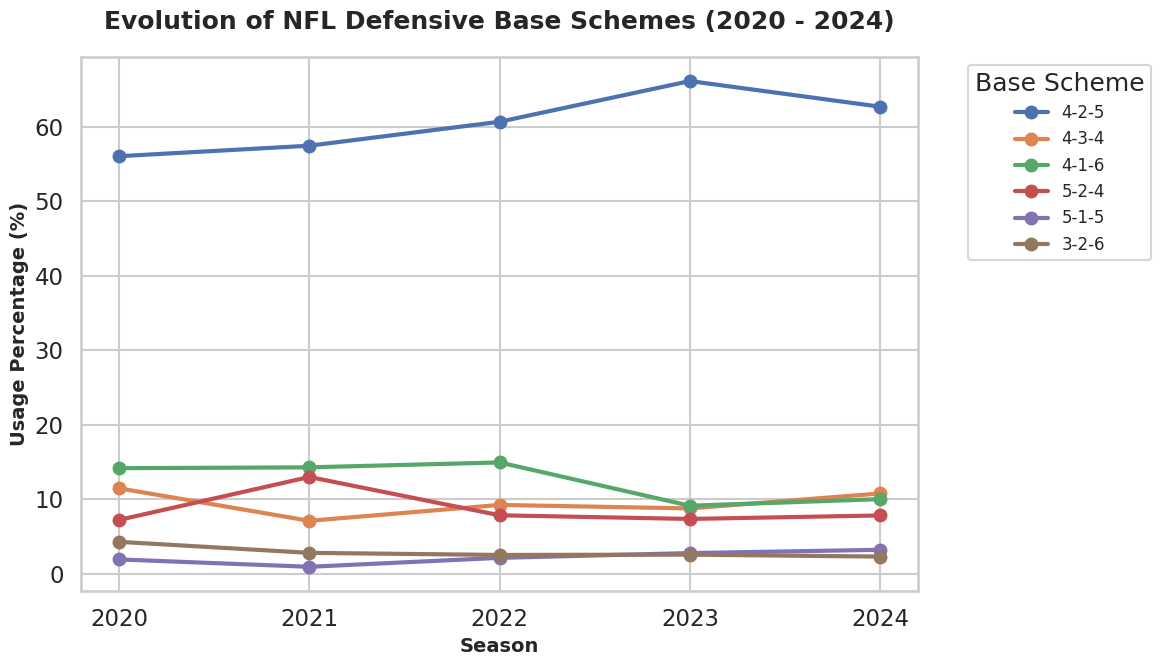

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- GENERATING ACADEMIC VISUALS ---")

# Set a clean, professional style for the paper's figures
sns.set_theme(style="whitegrid", context="talk")

# ==========================================
# CHART 1: The Evolution of Base Schemes
# ==========================================
plt.figure(figsize=(12, 7))

# Grab the top 6 most popular schemes to avoid cluttering the graph
top_schemes = scheme_trend.head(6).index
plot_data_schemes = scheme_trend.loc[top_schemes].T # Transpose so Years are on the X-axis

# Plot lines for each top scheme, showing their usage trend over seasons
for scheme in top_schemes:
    plt.plot(plot_data_schemes.index, plot_data_schemes[scheme], marker='o', linewidth=3, label=scheme)

plt.title('Evolution of NFL Defensive Base Schemes (2020 - 2024)', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Season', fontsize=14, fontweight='bold')
plt.ylabel('Usage Percentage (%)', fontsize=14, fontweight='bold')

# Ensure the x-axis only shows whole years for clarity
plt.xticks(plot_data_schemes.index, [str(int(year)) for year in plot_data_schemes.index])

# Place the legend outside the plot area to prevent it from obscuring data
plt.legend(title='Base Scheme', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout() # Adjust layout to prevent labels/titles from overlapping

# Save the image in high resolution for your paper
plt.savefig('base_scheme_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

--- 1. CALCULATING INDIVIDUAL ARCHETYPE USAGE ---

🏈 INDIVIDUAL ARCHETYPE USAGE (% OF PLAYS THEY ARE ON THE FIELD)


season,2020,2021,2022,2023,2024
dominant_cluster,,,,,
CB_0,16.82,14.47,12.23,7.55,11.74
CB_1,49.41,54.49,45.56,56.04,46.65
CB_2,29.10,22.75,32.67,21.90,24.58
CB_3,19.63,28.54,21.00,18.62,19.70
CB_4,86.83,83.85,88.94,96.90,91.40
CB_R,5.89,6.59,5.95,5.21,7.10
DI_0,23.70,33.94,31.29,32.51,35.16
DI_1,21.85,21.07,10.36,36.05,13.80
DI_2,51.23,32.09,31.51,28.63,37.77



--- 2. GENERATING VISUALS FOR CBs AND SAFETIES ---


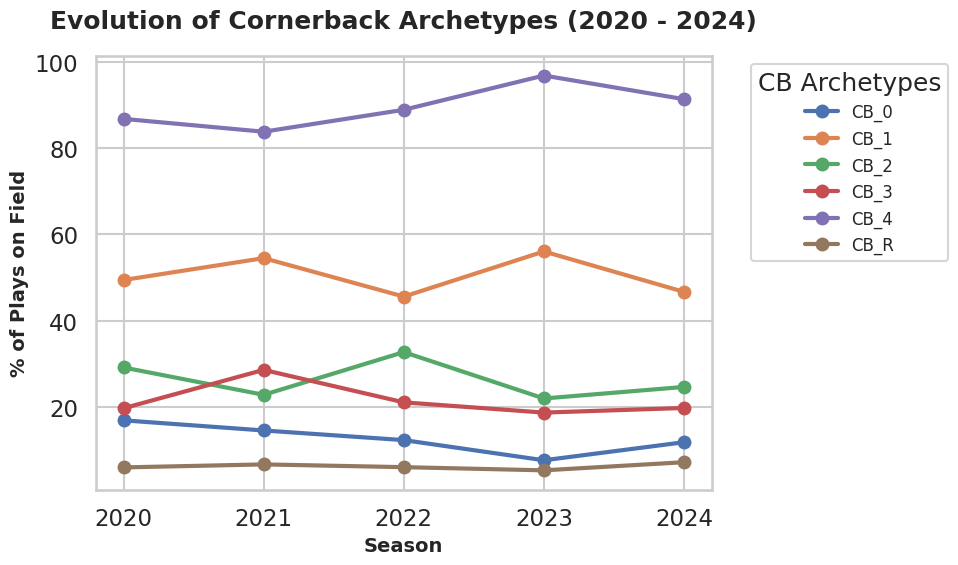

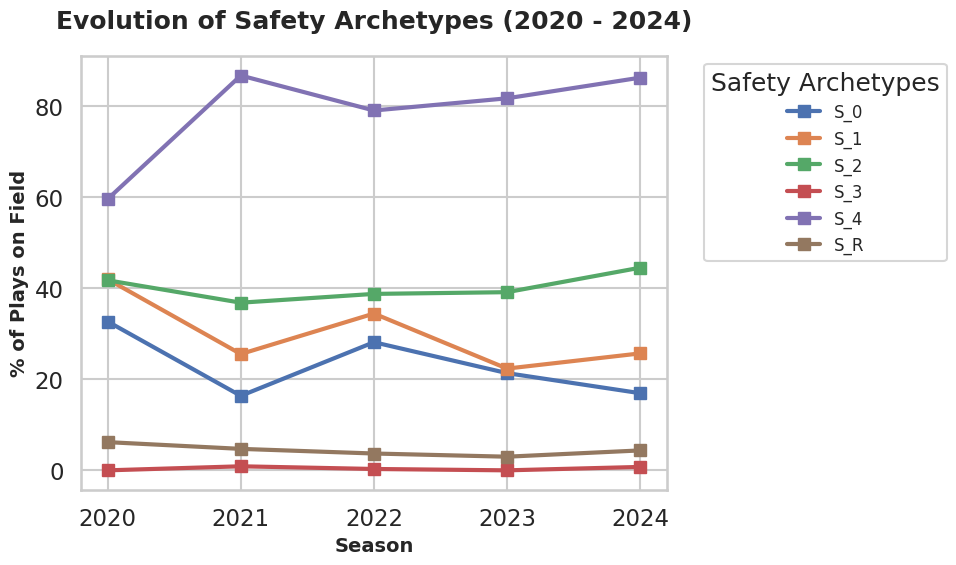


✅ Visuals successfully generated! Saved as 'cb_archetypes_evolution.png' and 'safety_archetypes_evolution.png'.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. CALCULATING INDIVIDUAL ARCHETYPE USAGE ---")
# Get total unique plays per season to calculate usage percentages
season_plays = play_defenders[['game_id', 'play_id', 'season']].drop_duplicates()
season_totals = season_plays.groupby('season').size().reset_index(name='Total_Season_Plays')

# To find how often an archetype is used, we drop duplicates by game, play, and cluster.
# This ensures that if a team plays two "CB_1"s on the same play, it just counts as "Yes, CB_1 was on the field once."
arch_presence = play_defenders[['game_id', 'play_id', 'season', 'dominant_cluster']].drop_duplicates()

# Count plays per archetype per season where that archetype was present
individual_arch_yoy = arch_presence.groupby(['season', 'dominant_cluster']).size().reset_index(name='Plays_Used')
individual_arch_yoy = individual_arch_yoy.merge(season_totals, on='season')

# Calculate Percentage of Plays that featured the individual archetype
individual_arch_yoy['Usage_Percent'] = (individual_arch_yoy['Plays_Used'] / individual_arch_yoy['Total_Season_Plays']) * 100

# Pivot for a clean table displaying archetype usage trends over years
arch_usage_trend = individual_arch_yoy.pivot(index='dominant_cluster', columns='season', values='Usage_Percent').fillna(0).round(2)

print("\n🏈 INDIVIDUAL ARCHETYPE USAGE (% OF PLAYS THEY ARE ON THE FIELD)")
display(arch_usage_trend)
arch_usage_trend.to_csv('individual_archetype_trends.csv')


print("\n--- 2. GENERATING VISUALS FOR CBs AND SAFETIES ---")
sns.set_theme(style="whitegrid", context="talk")

# Filter the index to grab just the Cornerback and Safety archetypes
cb_archetypes = [c for c in arch_usage_trend.index if str(c).startswith('CB')]
s_archetypes = [c for c in arch_usage_trend.index if str(c).startswith('S')]

# ==========================================
# CHART 1: Cornerback Archetypes Evolution
# ==========================================
plt.figure(figsize=(10, 6))
for cb in cb_archetypes:
    plt.plot(arch_usage_trend.columns, arch_usage_trend.loc[cb], marker='o', linewidth=3, label=cb)

plt.title('Evolution of Cornerback Archetypes (2020 - 2024)', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Season', fontsize=14, fontweight='bold')
plt.ylabel('% of Plays on Field', fontsize=14, fontweight='bold')
# Ensure x-axis shows whole years
plt.xticks(arch_usage_trend.columns, [str(int(year)) for year in arch_usage_trend.columns])
plt.legend(title='CB Archetypes', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('cb_archetypes_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# CHART 2: Safety Archetypes Evolution
# ==========================================
plt.figure(figsize=(10, 6))
for s in s_archetypes:
    plt.plot(arch_usage_trend.columns, arch_usage_trend.loc[s], marker='s', linewidth=3, label=s)

plt.title('Evolution of Safety Archetypes (2020 - 2024)', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Season', fontsize=14, fontweight='bold')
plt.ylabel('% of Plays on Field', fontsize=14, fontweight='bold')
# Ensure x-axis shows whole years
plt.xticks(arch_usage_trend.columns, [str(int(year)) for year in arch_usage_trend.columns])
plt.legend(title='Safety Archetypes', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('safety_archetypes_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visuals successfully generated! Saved as 'cb_archetypes_evolution.png' and 'safety_archetypes_evolution.png'.")

In [ ]:
# Filter prob_map for players whose dominant cluster is 'CB_2'
cb2_players = prob_map[prob_map['dominant_cluster'] == 'CB_2'].copy()

# Sort these players by their 'CB_2' probability in descending order to see the most representative ones
cb2_players = cb2_players.sort_values(by='CB_2', ascending=False).reset_index(drop=True)

# Select and display relevant columns for the CB_2 players
display(cb2_players[['player', 'season', 'CB_2', 'dominant_cluster', 'base_pos', 'scheme_pos']])

# Retrieve the EPA impact for the 'CB_2' archetype from the previously calculated cluster coefficients
# Note: There was a typo in the original code, it was looking for 'S_3' instead of 'CB_2'. Corrected here.
cb2_epa_impact = cluster_coefs[cluster_coefs['Archetype'] == 'CB_2']['EPA_Impact'].values[0]
print(f"\nEPA Impact for CB_2 Archetype: {cb2_epa_impact:.4f}")

,player,season,CB_2,dominant_cluster,base_pos,scheme_pos
0,Jonathan Jones,2021,1.00,CB_2,CB,CB
1,Nik Needham,2020,1.00,CB_2,CB,CB
2,Ka'dar Hollman,2020,1.00,CB_2,CB,CB
3,Joejuan Williams,2020,1.00,CB_2,CB,CB
4,Adoree' Jackson,2020,1.00,CB_2,CB,CB
...,...,...,...,...,...,...
97,Antonio Hamilton Sr.,2021,0.51,CB_2,CB,CB
98,Mike Sainristil,2024,0.50,CB_2,CB,CB
99,Josh Newton,2024,0.48,CB_2,CB,CB
100,Emmanuel Moseley,2020,0.46,CB_2,CB,CB



EPA Impact for CB_2 Archetype: 0.0131


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore') # Suppresses statsmodels convergence warnings for small groups

print("--- 1. CONSTRUCTING 11-MAN LINEUPS ---")

# Group all 11 players on a play into a single alphabetically sorted string to create a unique lineup identifier.
# This ensures that the order of players doesn't create 'different' combinations of the same lineup.
lineup_df = play_defenders.groupby(['game_id', 'play_id'])['dominant_cluster'].apply(
    lambda x: '_'.join(sorted(x)) if len(x) == 11 else None
).reset_index().rename(columns={'dominant_cluster': 'lineup_id'})

# Drop plays that didn't have exactly 11 mapped players (e.g., due to missing data or special team plays)
lineup_df = lineup_df.dropna(subset=['lineup_id'])

# Merge the lineup strings back into the main play-by-play data for analysis
# Ensure 'posteam' is included in the pbp dataframe for use in the mixed model
model_df = pbp.merge(lineup_df, on=['game_id', 'play_id'], how='inner')
model_df = model_df.dropna(subset=['epa', 'down', 'ydstogo', 'yardline_100', 'posteam'])

print("--- 2. FILTERING FOR SAMPLE SIZE ---")
# Mixed models require sufficient sample sizes to converge reliably.
# Filter for lineups that have been deployed at least MIN_SNAPS times.
MIN_SNAPS = 50
lineup_counts = model_df['lineup_id'].value_counts()
valid_lineups = lineup_counts[lineup_counts >= MIN_SNAPS].index

model_df = model_df[model_df['lineup_id'].isin(valid_lineups)].copy()

print(f"Running Mixed Model on {len(valid_lineups)} unique lineups over {len(model_df)} plays...")

print("--- 3. EXECUTING MIXED EFFECTS MODEL ---")
# Formula: Evaluate EPA based on the Lineup, while controlling for Down & Distance.
# 'C(lineup_id)' treats the lineup string as a categorical variable.
# '- 1' removes the intercept, so coefficients represent absolute EPA for each lineup.
formula = "epa ~ C(lineup_id) - 1 + down + ydstogo + yardline_100"

# Fit the mixed-effects model, using 'posteam' as the random effect to adjust for the offense's strength.
mixed_model = smf.mixedlm(formula, model_df, groups=model_df['posteam'])
mixed_fit = mixed_model.fit()

print("--- 4. EXTRACTING OPPONENT-ADJUSTED EPA ---")
# Extract the coefficients, standard errors, and p-values from the model results
results_df = pd.DataFrame({
    'Opponent_Adjusted_EPA': mixed_fit.params,
    'Std_Error': mixed_fit.bse,
    'P_Value': mixed_fit.pvalues
})

# Filter the results to only show the lineup coefficients (ignoring control variables)
lineup_results = results_df[results_df.index.str.contains('lineup_id')].copy()

# Clean up the index strings to make them more readable (remove "C(lineup_id)[" and "]")
lineup_results.index = lineup_results.index.str.replace('C(lineup_id)[', '', regex=False).str.replace(']', '', regex=False)

# Sort the results from best (most negative EPA) to worst (most positive EPA)
lineup_results = lineup_results.sort_values(by='Opponent_Adjusted_EPA')

# Prepare the results for display, matching the column names of archetype_epa for consistency
results_for_display = lineup_results.reset_index()
results_for_display = results_for_display.rename(columns={'index': 'Archetype_Lineup', 'Opponent_Adjusted_EPA': 'Avg_EPA'})

# Get the 'Plays' count for each lineup from the previously calculated lineup_counts
plays_df = lineup_counts.reset_index()
plays_df.columns = ['Archetype_Lineup', 'Plays']

# Merge 'Plays' count into the display DataFrame
results_for_display = results_for_display.merge(plays_df, on='Archetype_Lineup', how='left')

# 1. Merge lineup_df (which contains lineup_id) with scheme_df (which contains Base_Scheme)
lineup_scheme_mapping = lineup_df.merge(scheme_df, on=['game_id', 'play_id'], how='inner')

# 2. Drop duplicates to get a unique mapping from each lineup_id to its corresponding Base_Scheme
lineup_scheme_mapping = lineup_scheme_mapping[['lineup_id', 'Base_Scheme']].drop_duplicates()

# 3. Merge this mapping into results_for_display using 'Archetype_Lineup' as the join key
results_for_display = results_for_display.merge(lineup_scheme_mapping, left_on='Archetype_Lineup', right_on='lineup_id', how='left')

# Drop the redundant 'lineup_id' column if it was created during the merge
if 'lineup_id' in results_for_display.columns:
    results_for_display = results_for_display.drop(columns=['lineup_id'])

# Select and reorder columns for final display
final_display_columns = ['Archetype_Lineup', 'Base_Scheme', 'Plays', 'Avg_EPA', 'Std_Error', 'P_Value']
results_for_display = results_for_display[final_display_columns]

# Sort by Avg_EPA again to ensure the display shows the best lineups first
results_for_display = results_for_display.sort_values(by='Avg_EPA', ascending=True)

print("\n🔥 TOP 10 OPPONENT-ADJUSTED LINEUPS 🔥")
display(results_for_display.head(30)) # Display the top 30 lineups for a comprehensive view

# Save the output to a CSV file
results_for_display.to_csv("Opponent_Adjusted_Lineup_EPA.csv")
print("\nResults saved to 'Opponent_Adjusted_Lineup_EPA.csv'")

--- 1. CONSTRUCTING 11-MAN LINEUPS ---
--- 2. FILTERING FOR SAMPLE SIZE ---
Running Mixed Model on 150 unique lineups over 12643 plays...
--- 3. EXECUTING MIXED EFFECTS MODEL ---
--- 4. EXTRACTING OPPONENT-ADJUSTED EPA ---

🔥 TOP 10 OPPONENT-ADJUSTED LINEUPS 🔥


,Archetype_Lineup,Base_Scheme,Plays,Avg_EPA,Std_Error,P_Value
0,CB_1_CB_4_CB_4_DI_0_DI_1_ED_0_ED_1_LB_1_LB_1_S...,4-2-5,50,-0.460990,0.214639,0.031734
1,CB_4_CB_4_DI_2_DI_2_DI_3_ED_1_LB_1_LB_1_LB_2_S...,4-3-4,56,-0.368084,0.202663,0.069334
2,CB_2_CB_4_CB_4_DI_0_DI_0_ED_0_ED_1_LB_1_LB_1_S...,4-2-5,66,-0.366356,0.189044,0.052630
3,CB_2_CB_2_CB_4_DI_0_ED_0_ED_0_ED_1_LB_3_S_1_S_...,4-1-6,94,-0.320658,0.166165,0.053637
4,CB_2_CB_4_CB_4_DI_0_DI_0_ED_0_ED_1_LB_1_LB_1_S...,4-2-5,66,-0.231040,0.189574,0.222947
5,CB_1_CB_4_CB_4_DI_1_ED_0_ED_2_ED_3_LB_1_LB_1_S...,4-2-5,103,-0.218882,0.160875,0.173649
6,CB_2_CB_4_CB_4_DI_1_DI_1_ED_3_ED_3_LB_1_LB_1_S...,4-2-5,70,-0.218508,0.186334,0.240929
7,CB_1_CB_4_CB_4_DI_2_DI_3_ED_1_ED_3_LB_1_LB_1_S...,4-2-5,50,-0.210331,0.213394,0.324307
8,CB_0_CB_4_DI_0_ED_0_ED_2_ED_3_LB_1_LB_1_S_0_S_...,4-2-5,54,-0.201519,0.209973,0.337188
9,CB_1_CB_4_CB_4_DI_2_ED_0_ED_1_ED_2_LB_1_S_0_S_...,4-1-6,62,-0.200450,0.196919,0.308711



Results saved to 'Opponent_Adjusted_Lineup_EPA.csv'


### Examining a Top Opponent-Adjusted Lineup

In [ ]:
import numpy as np

# Get the top-performing lineup string from the first row of the sorted results
top_lineup_string = results_for_display.iloc[0]['Archetype_Lineup']
selected_base_scheme = results_for_display.iloc[0]['Base_Scheme']
selected_avg_epa = results_for_display.iloc[0]['Avg_EPA']

print(f"Analyzing the top lineup: '{top_lineup_string}'")
print(f"Base Scheme: {selected_base_scheme}")
print(f"Opponent-Adjusted Avg EPA: {selected_avg_epa:.4f}")

# Find a sample play (game_id and play_id) where this specific lineup was used
sample_play_info = model_df[model_df['lineup_id'] == top_lineup_string].iloc[0]
sample_game_id = sample_play_info['game_id']
sample_play_id = sample_play_info['play_id']

print(f"\nSample Play (Game ID: {sample_game_id}, Play ID: {sample_play_id})")

# Filter the 'play_defenders' DataFrame for players on the field during this specific sample play
players_on_field = play_defenders[
    (play_defenders['game_id'] == sample_game_id) &
    (play_defenders['play_id'] == sample_play_id)
].copy()

# Merge with 'prob_map' to get actual player names and other details for the players in this lineup
# Include 'season' in the merge key to ensure correct player identification across years
player_details = players_on_field.merge(
    prob_map[['gsis_id', 'season', 'player', 'dominant_cluster']], # Include season in the prob_map subset
    on=['gsis_id', 'season', 'dominant_cluster'], # Merge on gsis_id, season, and dominant_cluster
    how='left'
)

# Display the 11 players for this lineup, sorted by scheme position for readability
print("\nPlayers in this lineup for the sample play:")
display(player_details[['player', 'dominant_cluster', 'scheme_pos']].sort_values('scheme_pos'))

Analyzing the top lineup: 'CB_1_CB_4_CB_4_DI_0_DI_1_ED_0_ED_1_LB_1_LB_1_S_4_S_4'
Base Scheme: 4-2-5
Opponent-Adjusted Avg EPA: -0.4610

Sample Play (Game ID: 2022_01_KC_ARI, Play ID: 2630.0)

Players in this lineup for the sample play:


,player,dominant_cluster,scheme_pos
0,L'Jarius Sneed,CB_1,CB
4,Rashad Fenton,CB_4,CB
5,Jaylen Watson,CB_4,CB
2,Frank Clark,ED_0,DL
7,Tershawn Wharton,DI_0,DL
9,Chris Jones,DI_1,DL
10,George Karlaftis,ED_1,DL
3,Nick Bolton,LB_1,LB
6,Willie Gay,LB_1,LB
1,Juan Thornhill,S_4,S


### Counting Unique Player Combinations per Archetype Lineup

In [ ]:
# Merge lineup_df (which contains the archetype lineup string) with pbp_full (which has the actual player IDs)
player_archetype_mapping = lineup_df.merge(
    pbp_full[['game_id', 'play_id', 'defense_players']],
    on=['game_id', 'play_id'],
    how='inner'
)

# Create a unique identifier for each 11-player combination on a play.
# Sort the player IDs within the list to ensure that the order of players doesn't create 'different' combinations.
player_archetype_mapping['player_combo_id'] = player_archetype_mapping['defense_players'].apply(lambda x: '_'.join(sorted(x)))

# Group by the Archetype_Lineup (lineup_id) and count the number of unique player_combo_ids.
# This tells us how many different actual player groups correspond to each archetype lineup.
unique_player_combos_per_archetype = player_archetype_mapping.groupby('lineup_id')['player_combo_id'].nunique().reset_index()
unique_player_combos_per_archetype.rename(columns={'lineup_id': 'Archetype_Lineup', 'player_combo_id': 'Unique_Player_Combinations'}, inplace=True)

# Sort the results by the number of unique player combinations in descending order
unique_player_combos_per_archetype = unique_player_combos_per_archetype.sort_values(by='Unique_Player_Combinations', ascending=False)

print("\n🔥 Top Archetype Lineups by Number of Unique Player Combinations 🔥")
display(unique_player_combos_per_archetype.head(10))

# Save the results to CSV
unique_player_combos_per_archetype.to_csv('unique_player_combos_per_archetype.csv', index=False)
print("\n✅ Unique player combination counts saved to 'unique_player_combos_per_archetype.csv'")


🔥 Top Archetype Lineups by Number of Unique Player Combinations 🔥


,Archetype_Lineup,Unique_Player_Combinations
6799,CB_1_CB_4_CB_4_DI_2_DI_3_ED_1_ED_1_LB_0_LB_0_S...,53
6030,CB_1_CB_4_CB_4_DI_1_DI_2_ED_0_ED_0_LB_1_LB_1_S...,52
6028,CB_1_CB_4_CB_4_DI_1_DI_2_ED_0_ED_0_LB_1_LB_1_S...,48
6813,CB_1_CB_4_CB_4_DI_2_DI_3_ED_1_ED_1_LB_1_LB_1_S...,42
4827,CB_1_CB_4_CB_4_DI_0_DI_0_ED_1_ED_1_LB_0_LB_1_S...,42
6637,CB_1_CB_4_CB_4_DI_2_DI_2_ED_1_ED_1_LB_1_LB_1_S...,39
6735,CB_1_CB_4_CB_4_DI_2_DI_3_ED_0_ED_1_LB_0_LB_0_S...,37
4937,CB_1_CB_4_CB_4_DI_0_DI_1_ED_0_ED_0_LB_1_LB_1_S...,35
13402,CB_4_CB_4_DI_0_DI_1_ED_1_ED_2_LB_1_LB_1_S_2_S_...,31
7918,CB_1_CB_4_DI_0_DI_0_ED_1_ED_1_LB_0_LB_1_LB_1_S...,29



✅ Unique player combination counts saved to 'unique_player_combos_per_archetype.csv'
